请按要求编写一个银行账户管理系统。      
需要实现的功能：        
a. 创建账户     
需要提供姓名和密码（要求密码需要以 MD5 哈希值的形式存储）       
银行卡号自动生成        
支持预存款      
b. 删除账户     
需要验证卡号、姓名和密码        
c. 查询余额     
需要验证卡号和密码      
d. 存款     
需要验证卡号和密码      
输入金额        
e. 取款     
需要验证卡号和密码      
输入金额，并检查余额是否足够        
f. 转账     
需验证我方卡号和密码，验证对方卡号是否存在      
输入金额，并检查我方余额是否足够        
程序输入限制（如用户不按要求输入，必须予以纠正）：      
密码必须是 6 位数字     
金额必须是非负数        
卡号必须是正整数        
相关类的实现可以参考下面结构（当然你也可以按照自己的想法去构造）：      
PasswdMixin（Mixin 类，用于实现与密码相关的功能组件）;      
is_valid() -- 检测密码长度      
to_md5() -- 将明文密码转换为 MD5 存储       
Account（基本账户类）       
confirm_name() -- 确认姓名是否匹配      
confirm_passwd() -- 确认密码是否匹配        
withdraw() -- 取款      
deposit() -- 存款       
transfer() -- 转账      
get_balance() -- 查询余额       
UserManager（账户管理类）       
check_account() -- 检查账户是否存在及密码是否正确       
create_account() -- 创建账户        
delete_account() -- 删除账户        
get_account() -- 获取账户       
程序实现如下：      
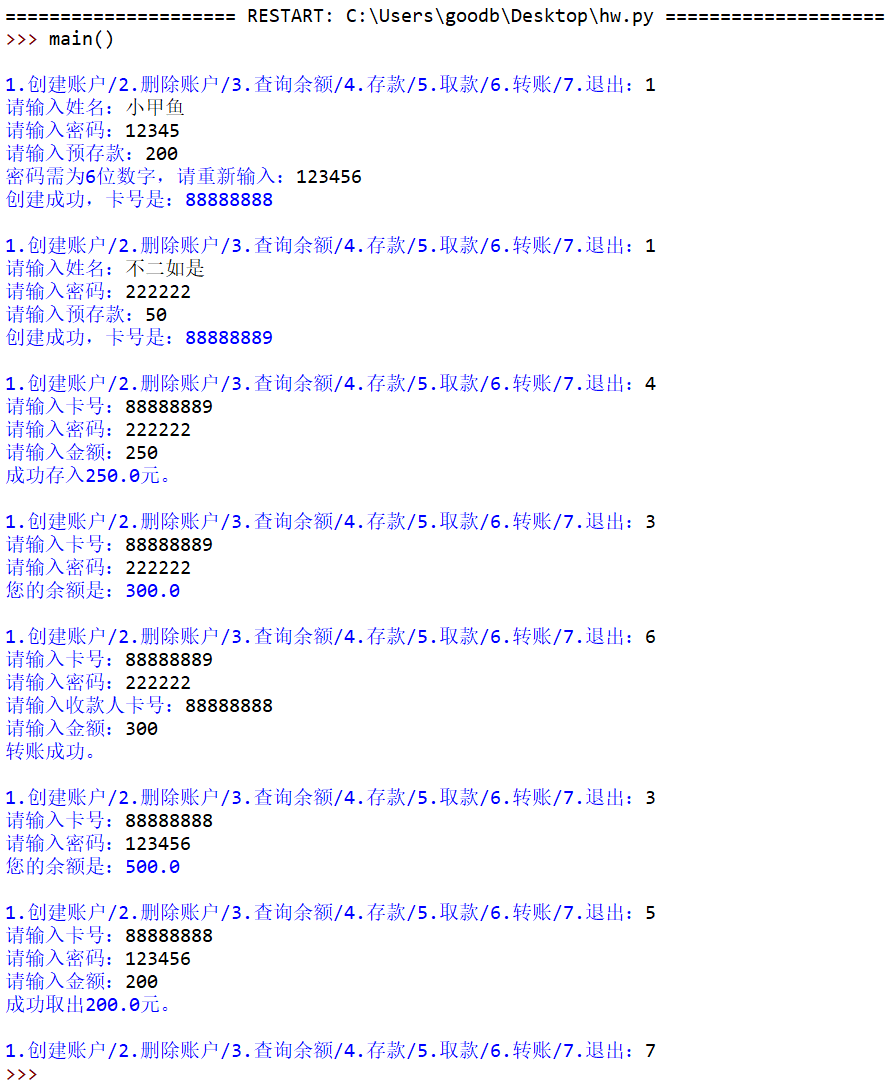

In [ ]:
import hashlib

class InputMixin:
    def passwd_is_valid(self, passwd):
        return len(passwd) == 6 and passwd.isdigit()

    def passwd_to_md5(self, passwd):
        md5 = hashlib.md5()
        md5.update(passwd.encode())
        return md5.hexdigest()

    def check_money(self, money):
        return money.isdigit() and float(money) >= 0


class Account(InputMixin):
    def __init__(self, username, password, cardid):
        self.username = username
        self.password = password
        self.cardid = cardid
        self.balance = 0.0

    def confirm_name(self, name):
        return self.username == name

    def confirm_passwd(self, passwd):
        return self.password == passwd

    def deposit(self):
        money = self.input_money()
        self.balance += money
        print(f'存款成功，存入{money}元，当前余额为{self.balance}元。')

    def withdraw(self):
        money = self.input_money()
        if money > self.balance:
            print('余额不足！')
            return
        self.balance -= money
        print(f'取款成功，取出{money}元，当前余额为{self.balance}元。')

    def get_balance(self):
        print(f"当前余额为{self.balance}元。")


class UserManager:
    def __init__(self):
        self.users_dict = {}
        self.next_cardid = 88888888

    def input_name(self):
        name = input('请输入姓名：')
        return name

    def input_passwd(self):
        passwd = input('请输入密码：')
        while not (len(passwd) == 6 and passwd.isdigit()):
            print('密码格式错误！')
            passwd = input('请输入密码：')
        md5 = hashlib.md5()
        md5.update(passwd.encode())
        return md5.hexdigest()

    def input_cardid(self):
        cardid = input("请输入卡号：")
        while not (cardid.isdigit() and int(cardid) > 0):
            print('卡号必须是正整数！')
            cardid = input("请输入卡号：")
        return cardid

    def input_transfer_cardid(self):
        cardid = input("请输入收款人卡号：")
        return cardid

    def input_money(self):
        money = input('请输入金额：')
        while not (money.isdigit() and float(money) >= 0):
            print('金额格式错误！')
            money = input('请输入金额：')
        return float(money)

    def create_account(self):
        name = self.input_name()
        password = self.input_passwd()
        cardid = str(self.next_cardid)
        user = Account(name, password, cardid)
        self.users_dict[cardid] = user
        self.next_cardid += 1
        print(f'创建成功，卡号为 {cardid}，关联用户 -> {name}')

    def delete_account(self):
        cardid = self.input_cardid()
        if cardid not in self.users_dict:
            print("无此用户！")
            return
        password = self.input_passwd()
        if not self.users_dict[cardid].confirm_passwd(password):
            print("密码错误！")
            return
        name = self.input_name()
        if not self.users_dict[cardid].confirm_name(name):
            print("姓名错误！")
            return
        username = self.users_dict[cardid].username
        del self.users_dict[cardid]
        print(f'删除成功，卡号为 {cardid}，关联用户 -> {username}')

    def login(self):
        cardid = self.input_cardid()
        if cardid not in self.users_dict:
            print("无此用户！")
            return None
        password = self.input_passwd()
        if not self.users_dict[cardid].confirm_passwd(password):
            print("密码错误！")
            return None
        print(f'登录成功，卡号为 {cardid}，关联用户 -> {self.users_dict[cardid].username}')
        return cardid

    def transfer(self, cardid):
        target_cardid = self.input_transfer_cardid()
        if target_cardid == cardid:
            print("不能给自己转账！")
            return
        if target_cardid not in self.users_dict:
            print("收款人不存在！")
            return
        money = self.input_money()
        if money > self.users_dict[cardid].balance:
            print('余额不足！')
            return
        self.users_dict[cardid].balance -= money
        self.users_dict[target_cardid].balance += money
        print(f'转账成功，转账{money}元，当前余额为{self.users_dict[cardid].balance}元。')


def main():
    manager = UserManager()
    print("欢迎使用鱼C银行账户管理系统~")
    while True:
        print("1.创建账户\n2.删除账户\n3.登录账户\n4.退出")
        choice_manager = input("请选择需要的功能：")
        if choice_manager == "1":
            manager.create_account()
        elif choice_manager == "2":
            manager.delete_account()
        elif choice_manager == "3":
            cardid = manager.login()
            if cardid:
                while True:
                    print("1.查询余额\n2.存款\n3.取款\n4.转账\n5.退出")
                    choice_account = input("请选择需要的功能：")
                    if choice_account == "1":
                        manager.users_dict[cardid].get_balance()
                    elif choice_account == "2":
                        manager.users_dict[cardid].deposit()
                    elif choice_account == "3":
                        manager.users_dict[cardid].withdraw()
                    elif choice_account == "4":
                        manager.transfer(cardid)
                    elif choice_account == "5":
                        print("退出成功！")
                        break
                    else:
                        print("输入错误！")
        elif choice_manager == "4":
            print("感谢使用鱼C银行账户管理系统~")
            break
        else:
            print("输入错误！")


if __name__ == "__main__":
    main()